In [2]:
from __future__ import print_function


import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter


from six.moves import xrange

import umap

import hydra
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
from PIL import Image


import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import tempfile
tempfile.tempdir = "/home/sbanerjee/tmp"

from torch.utils.data import DataLoader
from streaming import StreamingDataset

/home/sbanerjee/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset

Because `predownload` was not specified, it will default to 8*batch_size if batch_size is not None, otherwise 64. Prior to Streaming v0.7.0, `predownload` defaulted to max(batch_size, 256 * batch_size // num_canonical_nodes).
Because `num_canonical_nodes` was not specified, and `shuffle_algo` is py1e, it will default to be equal to physical nodes. Prior to Streaming v0.7.0, `num_canonical_nodes` defaulted to 64 * physical nodes.
Because `shuffle_block_size` was not specified, it will default to max(4_000_000 // num_canonical_nodes, 1 << 18) if num_canonical_nodes is not None, otherwise 262144. Prior to Streaming v0.7.0, `shuffle_block_size` defaulted to 262144.


Sample 0:
Shape of image: (100, 200, 3)
region: chr1:866460-866659
Processing sample 0, region: chr1:866460-866659


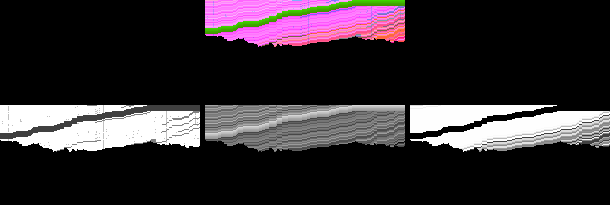

In [5]:
def flatten_image(image_tensor, select_channels=[0, 1, 2], margin=5, render_channels=False):
    #Renders a combined image from the selected channels of an image tensor.
    # Create RGB image from selected channels
    combined_image = Image.fromarray(image_tensor[:, :, select_channels], mode="RGB")

    if render_channels:
        height, width, _ = image_tensor.shape
        num_channels = len(select_channels)
        image = Image.new("RGB", (width + (num_channels - 1) * (width + margin), 2 * height + margin))
        image.paste(combined_image, ((image.width - width) // 2, 0))

        for i, channel in enumerate(select_channels):
            channel_image = Image.fromarray(image_tensor[:, :, channel], mode="L")
            channel_image = channel_image.convert("RGB")  # Convert grayscale to RGB for consistent pasting
            coord = (i * (width + margin), height + margin)
            image.paste(channel_image, coord)

        return image
    else:
        return combined_image


remote_dir = '/storage/mlinderman/projects/sv/npsv3-experiments/training/freeze4.sv.alt.passing.training.hg38.images/HG00731/generator=coverage,simulation.replicates=1/000'


with tempfile.TemporaryDirectory() as local_dir:
    dataset = StreamingDataset(local=local_dir, remote=remote_dir, split=None, shuffle=False)
    for i, sample in enumerate(dataset):
        image_tensor = sample['image']  
        image_tensor = image_tensor[:, :, :3]  # This slices the tensor to keep only the first 3 channels
        
        # Update the sample dictionary with the modified image
        sample['image'] = image_tensor
        # Proceed with your processing
        print(f"Sample {i}:")
        for key, value in sample.items():
            if key == 'image':
                print(f"Shape of {key}: {value.shape}")
            else:
                print(f"{key}: {value}")
        print(f"Processing sample {i}, region: {sample['region']}")
        
        # Render the image using function
        rendered_image = flatten_image(image_tensor, render_channels=True)
        rendered_image.show()  
        
        if i == 0:  # Only process the first sample for this example
            break
dataloader = DataLoader(dataset)

Dataset Transformations

In [ ]:
from torch.utils.data import Dataset

class Dataset(Dataset):
    def __init__(self, remote_dir, transform=None):
        """
        Args:
            remote_dir (string): Directory with all the images or path to your dataset.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.remote_dir = remote_dir
        self.transform = transform
        self.temp_dir = tempfile.TemporaryDirectory()  # Create a temporary directory
        self.dataset = StreamingDataset(local=self.temp_dir.name, remote=remote_dir, split=None, shuffle=False)
        self.images = list(self.dataset)  # Load the dataset; may need adjustment for very large datasets

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        sample = self.images[idx]
        image = sample['image'][:, :, :3]  # Keep only the first three channels
        image = Image.fromarray(image.astype('uint8'), 'RGB')  # Convert to PIL Image

        if self.transform:
            image = self.transform(image)
            #print(f"Shape of image: {image.shape}")  # Print the shape of the image
        
        return image

    def close(self):
        self.temp_dir.cleanup()  # Clean up the temporary directory

# Define transformations: resize to 32x32, convert to tensor, and normalize
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalizing for RGB
])

# Initialize your custom dataset with transformations
remote_dir = '/storage/mlinderman/projects/sv/npsv3-experiments/training/freeze4.sv.alt.passing.training.hg38.images/HG00731/generator=coverage,simulation.replicates=1/000'
custom_dataset = Dataset(remote_dir, transform=transform)
dataloader = DataLoader(custom_dataset, batch_size=32, shuffle=True)
#images = next(iter(dataloader))


Residual Blocks

In [18]:
class Residual(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            nn.Conv2d(in_channels=in_channels, out_channels=num_residual_hiddens, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(True),
            nn.Conv2d(in_channels=num_residual_hiddens, out_channels=num_hiddens, kernel_size=1, stride=1, bias=False)
        )

    def forward(self, x):
        return x + self._block(x)

class ResidualStack(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens):
        super(ResidualStack, self).__init__()
        self._layers = nn.ModuleList([Residual(in_channels, num_hiddens, num_residual_hiddens) for _ in range(num_residual_layers)])

    def forward(self, x):
        for layer in self._layers:
            x = layer(x)
        return F.relu(x)

Encoder

In [19]:
class Encoder(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens):
        super(Encoder, self).__init__()
        self._conv_1 = nn.Conv2d(in_channels=in_channels, out_channels=num_hiddens//2, kernel_size=4, stride=2, padding=1)
        self._conv_2 = nn.Conv2d(in_channels=num_hiddens//2, out_channels=num_hiddens, kernel_size=4, stride=2, padding=1)
        self._conv_3 = nn.Conv2d(in_channels=num_hiddens, out_channels=num_hiddens, kernel_size=3, stride=1, padding=1)
        self._residual_stack = ResidualStack(in_channels=num_hiddens, num_hiddens=num_hiddens, num_residual_layers=num_residual_layers, num_residual_hiddens=num_residual_hiddens)

    def forward(self, inputs):
        x = F.relu(self._conv_1(inputs))
        x = F.relu(self._conv_2(x))
        x = self._conv_3(x)
        return self._residual_stack(x)

Decoder

In [20]:
class Decoder(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens):
        super(Decoder, self).__init__()
        self._conv_1 = nn.Conv2d(in_channels=in_channels, out_channels=num_hiddens, kernel_size=3, stride=1, padding=1)
        self._residual_stack = ResidualStack(in_channels=num_hiddens, num_hiddens=num_hiddens, num_residual_layers=num_residual_layers, num_residual_hiddens=num_residual_hiddens)
        self._conv_trans_1 = nn.ConvTranspose2d(in_channels=num_hiddens, out_channels=num_hiddens//2, kernel_size=4, stride=2, padding=1)
        self._conv_trans_2 = nn.ConvTranspose2d(in_channels=num_hiddens//2, out_channels=3, kernel_size=4, stride=2, padding=1)  # Note: Output adjusted for RGB

    def forward(self, inputs):
        x = self._conv_1(inputs)
        x = self._residual_stack(x)
        x = F.relu(self._conv_trans_1(x))
        return self._conv_trans_2(x)

Train

In [ ]:
batch_size = 64
num_training_updates = 150

num_hiddens = 128
num_residual_hiddens = 32
num_residual_layers = 2

embedding_dim = 64
num_embeddings = 512

commitment_cost = 0.25

decay = 0.99

learning_rate = 1e-3

In [ ]:
training_loader = DataLoader(training_data,
                             batch_size=batch_size,
                             shuffle=True
                             pin_memory=True)


validation_loader = DataLoader(validation_data,
                               batch_size=32,
                               shuffle=True,
                               pin_memory=True)

In [ ]:
class Model(nn.Module):
    def __init__(self, num_hiddens, num_residual_layers, num_residual_hiddens,
                 num_embeddings, embedding_dim, commitment_cost, decay=0):
        super(Model, self).__init__()

        self._encoder = Encoder(3, num_hiddens,
                                num_residual_layers,
                                num_residual_hiddens)
        self._pre_vq_conv = nn.Conv2d(in_channels=num_hiddens,
                                      out_channels=embedding_dim,
                                      kernel_size=1,
                                      stride=1)
        if decay > 0.0:
            self._vq_vae = VectorQuantizerEMA(num_embeddings, embedding_dim,
                                              commitment_cost, decay)
        else:
            self._vq_vae = VectorQuantizer(num_embeddings, embedding_dim,
                                           commitment_cost)
        self._decoder = Decoder(embedding_dim,
                                num_hiddens,
                                num_residual_layers,
                                num_residual_hiddens)

    def forward(self, x):
        z = self._encoder(x)
        z = self._pre_vq_conv(z)
        loss, quantized, perplexity, _ = self._vq_vae(z)
        x_recon = self._decoder(quantized)

        return loss, x_recon, perplexity

In [ ]:
model = Model(num_hiddens, num_residual_layers, num_residual_hiddens,
              num_embeddings, embedding_dim,
              commitment_cost, decay).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

In [ ]:
model.train()
train_res_recon_error = []
train_res_perplexity = []

for i in xrange(num_training_updates):
    (data, _) = next(iter(training_loader))
    data = data.to(device)
    optimizer.zero_grad()

    vq_loss, data_recon, perplexity = model(data)
    recon_error = F.mse_loss(data_recon, data) / data_variance
    loss = recon_error + vq_loss
    loss.backward()

    optimizer.step()

    train_res_recon_error.append(recon_error.item())
    train_res_perplexity.append(perplexity.item())

    if (i+1) % 100 == 0:
        print('%d iterations' % (i+1))
        print('recon_error: %.3f' % np.mean(train_res_recon_error[-100:]))
        print('perplexity: %.3f' % np.mean(train_res_perplexity[-100:]))
        print()